# Extracción de Features, Similitud y Transfer Learning
| IA 5.2 Computer Vision
| FCEIA - UNR

Continuando desde CNN y ResNet50, en este cuaderno exploramos cómo convertir un clasificador en un **extractor de features**, qué se puede hacer con esos vectores (búsqueda por similitud, reconocimiento facial) y cómo adaptar modelos pre-entrenados a nuevas tareas con **transfer learning** y **fine-tuning**.

**Contenido**

1. [Del clasificador al extractor de features](#1-del-clasificador-al-extractor-de-features)
2. [Búsqueda por similitud de imágenes](#2-busqueda-por-similitud)
3. [Camino al reconocimiento facial](#3-reconocimiento-facial)
4. [Transfer Learning y Fine-Tuning con ResNet18](#4-transfer-learning-y-fine-tuning)
5. [Detección de objetos en video](#5-deteccion-en-video)

# Librerías a utilizar

In [1]:
# !pip install torch torchvision scikit-learn

In [2]:
import ssl
import io
import os
import urllib.request

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as models
import torchvision.transforms as T
import torchvision.datasets as datasets
from torchvision.models import ResNet50_Weights, ResNet18_Weights
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
)
from torchvision.utils import draw_bounding_boxes
import torchvision.transforms.functional as TF

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageDraw
from sklearn.decomposition import PCA

print(f"PyTorch:      {torch.__version__}")
print(f"Torchvision:  {torchvision.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo:  {device}")

# ── Helpers de carga de imágenes ──────────────────────────────────────────────
_ssl_ctx = ssl.create_default_context()
_ssl_ctx.check_hostname = False
_ssl_ctx.verify_mode = ssl.CERT_NONE

def descargar_imagen(url, timeout=8):
    try:
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=timeout, context=_ssl_ctx) as r:
            return Image.open(io.BytesIO(r.read())).convert("RGB")
    except Exception:
        return None

def imagen_sintetica(color_rgb=(128, 128, 128), size=(224, 224)):
    arr = np.full((size[1], size[0], 3), color_rgb, dtype=np.uint8)
    ruido = np.random.randint(-25, 25, arr.shape, dtype=np.int16)
    arr = np.clip(arr.astype(np.int16) + ruido, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

def cargar_imagen(ruta_local, url_fallback, color_fallback=(128, 128, 128)):
    if ruta_local and os.path.exists(ruta_local):
        print(f"[OK] Local: {ruta_local}")
        return Image.open(ruta_local).convert("RGB")
    img = descargar_imagen(url_fallback)
    if img is not None:
        print(f"[OK] Web: {url_fallback[:55]}...")
        return img
    print(f"[--] Sintética (color {color_fallback})")
    return imagen_sintetica(color_fallback)

PyTorch:      2.10.0+cu128
Torchvision:  0.25.0+cu128
Dispositivo:  cuda


---
# 1. Del Clasificador al Extractor de Features

ResNet50 en su configuración estándar termina en una capa `fc` que proyecta el vector de **2048 dimensiones** del `avgpool` a **1000 clases** de ImageNet.

La capa `fc` es **intercambiable**. Las 2048 dimensiones que produce el `avgpool` son una descripción rica y compacta de la imagen: no son píxeles, son **características semánticas aprendidas** durante el entrenamiento en millones de imágenes.

```
Imagen (3×224×224)
        ↓
  ┌──────────────────────────────────────────────────┐
  │  [Backbone ResNet50]                             │
  │  Stem → Layer1 → Layer2 → Layer3 → Layer4       │
  └──────────────────────────────────────────────────┘
        ↓
  [avgpool]  ──→  vector 2048-dim  ──→  [fc]  ──→  1000 clases
                        ↑
                  ✂ Cortamos aquí
                        ↓
                  vector 2048-dim  ←  📐 Feature vector
```

Reemplazar `fc` por `nn.Identity()` hace que el modelo devuelva el vector directamente.

In [3]:
# ── Cargamos ResNet50 y mostramos las capas finales ──────────────────────────
backbone = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
backbone.eval()

print("Capas finales del clasificador:")
print(f"  avgpool: {backbone.avgpool}")
print(f"  fc:      {backbone.fc}")
print(f"\nDimensión de entrada al fc:  {backbone.fc.in_features}  (features)")
print(f"Dimensión de salida del fc:  {backbone.fc.out_features}  (clases ImageNet)")

# ── Creamos el extractor: fc → Identity ──────────────────────────────────────
extractor = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
extractor.fc = nn.Identity()
extractor.eval()

# Verificamos shapes con una imagen aleatoria
img_prueba = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    sal_clasif  = backbone(img_prueba)
    sal_extract = extractor(img_prueba)

print(f"\nSalida clasificador: {sal_clasif.shape}   → (batch, 1000 clases)")
print(f"Salida extractor:    {sal_extract.shape}  → (batch, 2048 features)")

Capas finales del clasificador:
  avgpool: AdaptiveAvgPool2d(output_size=(1, 1))
  fc:      Linear(in_features=2048, out_features=1000, bias=True)

Dimensión de entrada al fc:  2048  (features)
Dimensión de salida del fc:  1000  (clases ImageNet)

Salida clasificador: torch.Size([1, 1000])   → (batch, 1000 clases)
Salida extractor:    torch.Size([1, 2048])  → (batch, 2048 features)


## 1.1 Galería de imágenes y extracción de features

Cargamos imágenes de distintas categorías y le pedimos al extractor el vector de cada una.

In [4]:
from torchvision.datasets import STL10

# STL-10: 10 clases × 800 imágenes de 96×96 (split test)
# Derivado de ImageNet — mismas categorías visuales que CIFAR-10 pero 9× más resolución
STL10_CLASES = ["avion", "pajaro", "auto", "gato", "ciervo",
                "perro", "caballo", "mono", "barco", "camion"]
# Mapeo label (0-9) → nombre en español
CLASES_GALERIA = STL10_CLASES   # alias corto para el resto del notebook

transform_imagenet = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
transform_vis = T.Compose([T.Resize(128), T.CenterCrop(96), T.ToTensor()])

# split="test" tiene 8 000 imágenes etiquetadas (800 por clase)
# El archivo completo pesa ~2.5 GB (incluye 100 K imágenes no etiquetadas).
# Solo se descarga la primera vez; luego queda cacheado en ./data.
print("Descargando STL-10 (~2.5 GB, solo la primera vez — puede tardar unos minutos)...")
stl_feat = STL10(root="./data", split="test", download=True,
                  transform=transform_imagenet)
stl_vis  = STL10(root="./data", split="test", download=False,
                  transform=transform_vis)
print(f"Split test cargado: {len(stl_feat)} imágenes  |  clases: {stl_feat.classes}")

# Seleccionamos N_POR_CLASE muestras por clase (recorremos el dataset UNA sola vez)
N_POR_CLASE = 5
indices_por_clase = {i: [] for i in range(len(STL10_CLASES))}
for idx, (_, label) in enumerate(stl_feat):
    if len(indices_por_clase[label]) < N_POR_CLASE:
        indices_por_clase[label].append(idx)
    if all(len(v) >= N_POR_CLASE for v in indices_por_clase.values()):
        break

imagenes_pil = {}
features     = {}

print("\nExtrayendo features...")
extractor.eval()
for label, nombre_clase in enumerate(STL10_CLASES):
    for i, idx in enumerate(indices_por_clase[label]):
        clave = f"{nombre_clase}_{i+1}"
        img_vis,  _ = stl_vis[idx]
        img_feat, _ = stl_feat[idx]
        imagenes_pil[clave] = TF.to_pil_image(img_vis.clamp(0, 1))
        with torch.no_grad():
            feat = extractor(img_feat.unsqueeze(0))
        features[clave] = feat.squeeze(0).cpu()

dim = list(features.values())[0].shape[0]
print(f"\n✓ {len(features)} imágenes  ({N_POR_CLASE} por clase × {len(STL10_CLASES)} clases)")
print(f"  Resolución original: 96×96 px  |  Dim. de cada vector: {dim}")

Descargando STL-10 (~2.5 GB, solo la primera vez — puede tardar unos minutos)...


100.0%


Split test cargado: 8000 imágenes  |  clases: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']

Extrayendo features...

✓ 50 imágenes  (5 por clase × 10 clases)
  Resolución original: 96×96 px  |  Dim. de cada vector: 2048


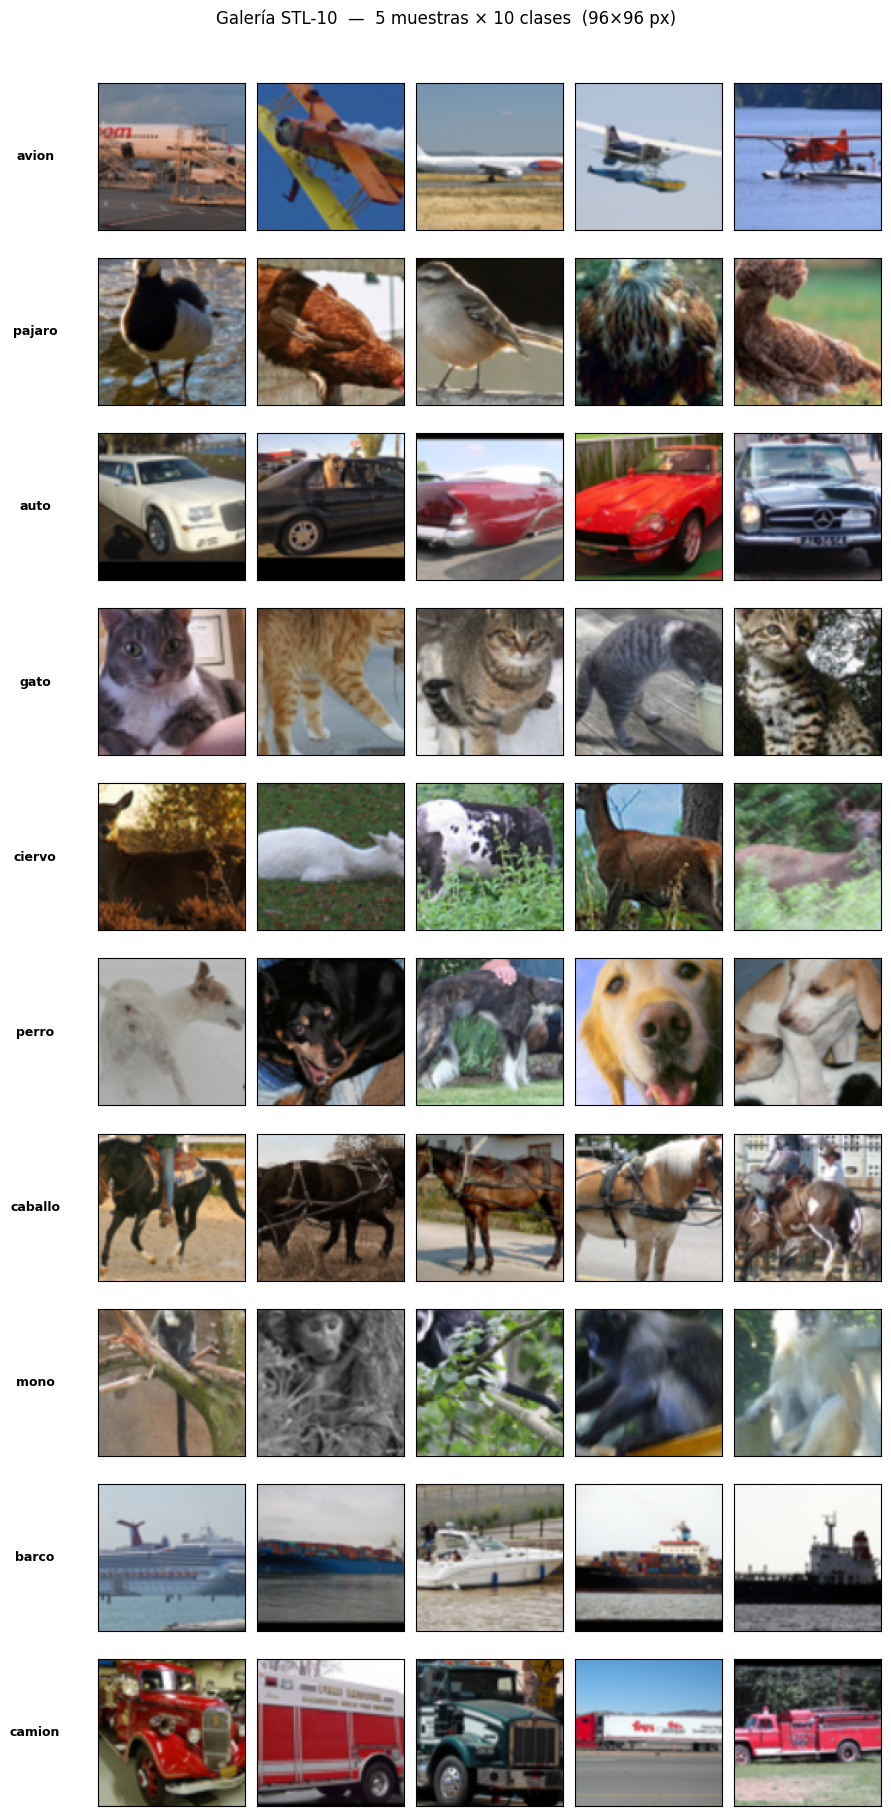

In [5]:
fig, axes = plt.subplots(len(CLASES_GALERIA), N_POR_CLASE,
                          figsize=(N_POR_CLASE * 1.8, len(CLASES_GALERIA) * 1.8))
for fila, nombre_clase in enumerate(CLASES_GALERIA):
    for col in range(N_POR_CLASE):
        clave = f"{nombre_clase}_{col+1}"
        ax = axes[fila, col]
        ax.imshow(imagenes_pil[clave])
        if col == 0:
            ax.set_ylabel(nombre_clase, fontsize=9, rotation=0,
                          labelpad=45, va="center", fontweight="bold")
        ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f"Galería STL-10  —  {N_POR_CLASE} muestras × {len(CLASES_GALERIA)} clases  (96×96 px)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 1.2 ¿Qué hay dentro del vector de features?

Cada una de las 2048 posiciones es la activación de un "neuróno detector" que aprendió a responder a algún concepto visual. No sabemos exactamente qué detecta cada uno, pero el conjunto forma una huella única de la imagen.

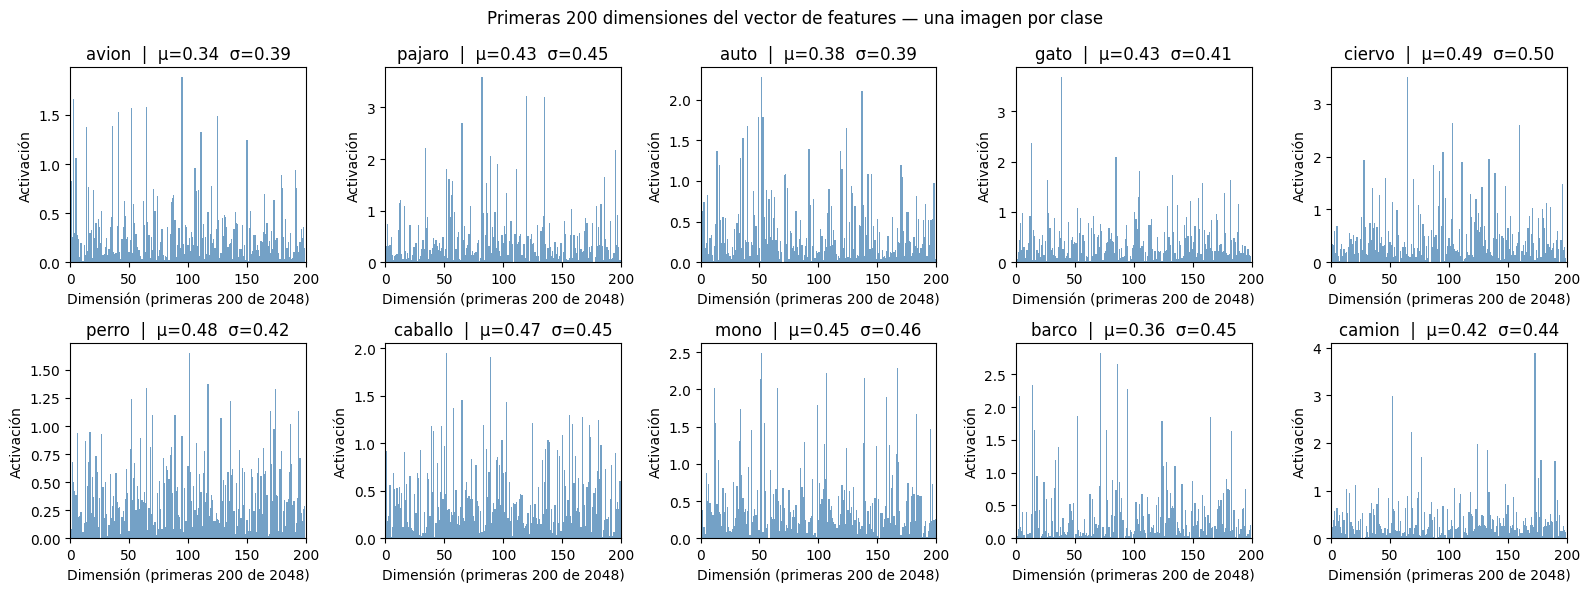

In [6]:
# Primeras 200 dimensiones del vector de features — primera muestra por clase
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, nombre_clase in zip(axes.flat, CLASES_GALERIA):
    clave = f"{nombre_clase}_1"
    f = features[clave].numpy()
    ax.bar(range(200), f[:200], width=1.0, color="steelblue", alpha=0.75)
    ax.set_title(f"{nombre_clase}  |  μ={f.mean():.2f}  σ={f.std():.2f}")
    ax.set_xlabel("Dimensión (primeras 200 de 2048)")
    ax.set_ylabel("Activación")
    ax.set_xlim(0, 200)
plt.suptitle("Primeras 200 dimensiones del vector de features — una imagen por clase", fontsize=12)
plt.tight_layout()
plt.show()

---
# 2. Búsqueda por Similitud

Si dos imágenes tienen vectores parecidos, las imágenes son **semánticamente similares**. Pero ¿cómo medimos "parecido" en un espacio de 2048 dimensiones?

## 2.1 Similitud del Coseno

La **similitud del coseno** mide el ángulo entre dos vectores, independientemente de su magnitud:

$$\text{sim}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \cdot \|\mathbf{b}\|}$$

- **+1** → vectores idénticos (mismo ángulo)
- **0** → ortogonales (sin relación)
- **−1** → opuestos

Es la métrica estándar en búsqueda por similitud de imágenes, texto y audio porque es invariante a la escala.

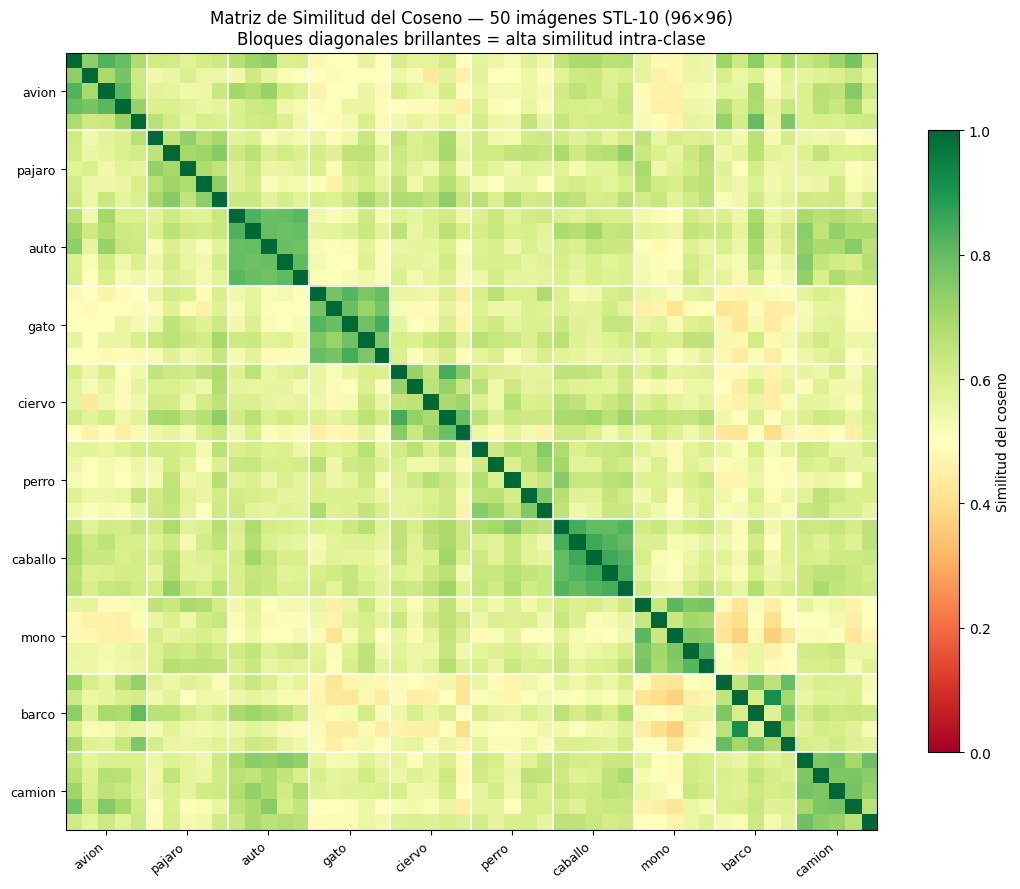

Similitud media  INTRA-clase: 0.7401
Similitud media  INTER-clase: 0.5748
Ratio intra/inter:            1.29x  (>1 = separación semántica)


In [7]:
nombres = list(features.keys())   # 50 claves, ordenadas clase a clase
n       = len(nombres)
sim_mat = torch.zeros(n, n)

for i, n1 in enumerate(nombres):
    for j, n2 in enumerate(nombres):
        sim_mat[i, j] = F.cosine_similarity(
            features[n1].unsqueeze(0), features[n2].unsqueeze(0)
        ).item()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(sim_mat.numpy(), cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Similitud del coseno", shrink=0.8)

# Ticks centrados en el bloque de cada clase
tick_pos = [N_POR_CLASE * i + N_POR_CLASE // 2 for i in range(len(CLASES_GALERIA))]
ax.set_xticks(tick_pos)
ax.set_xticklabels(CLASES_GALERIA, rotation=40, ha="right", fontsize=9)
ax.set_yticks(tick_pos)
ax.set_yticklabels(CLASES_GALERIA, fontsize=9)

# Líneas divisorias entre bloques de clase
for k in range(1, len(CLASES_GALERIA)):
    pos = k * N_POR_CLASE - 0.5
    ax.axhline(pos, color="white", lw=1.5, alpha=0.8)
    ax.axvline(pos, color="white", lw=1.5, alpha=0.8)

ax.set_title(f"Matriz de Similitud del Coseno — {n} imágenes STL-10 (96×96)\n"
             "Bloques diagonales brillantes = alta similitud intra-clase", fontsize=12)
plt.tight_layout()
plt.show()

# Métricas intra vs inter clase
intra, inter = [], []
for i in range(n):
    ci = i // N_POR_CLASE
    for j in range(n):
        if i == j: continue
        cj = j // N_POR_CLASE
        (intra if ci == cj else inter).append(sim_mat[i, j].item())

print(f"Similitud media  INTRA-clase: {np.mean(intra):.4f}")
print(f"Similitud media  INTER-clase: {np.mean(inter):.4f}")
print(f"Ratio intra/inter:            {np.mean(intra)/np.mean(inter):.2f}x  (>1 = separación semántica)")

## 2.2 Búsqueda por Query — Top-K Imágenes Similares

Dado un **query** (imagen de consulta), queremos encontrar las *k* imágenes más similares dentro de una galería.

/tmp/ipykernel_30302/4294195577.py:33: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/tino/Documentos/Projects/facultad/CV/IA5.2_Computer_Vision/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


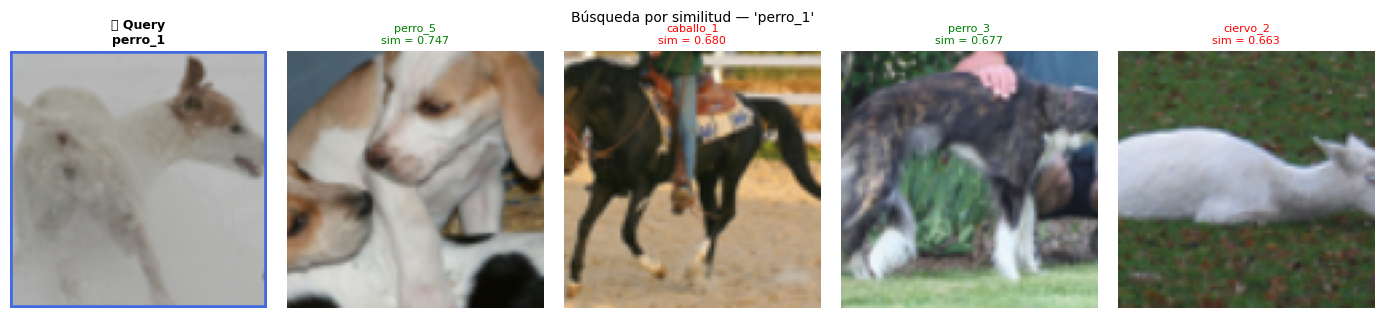

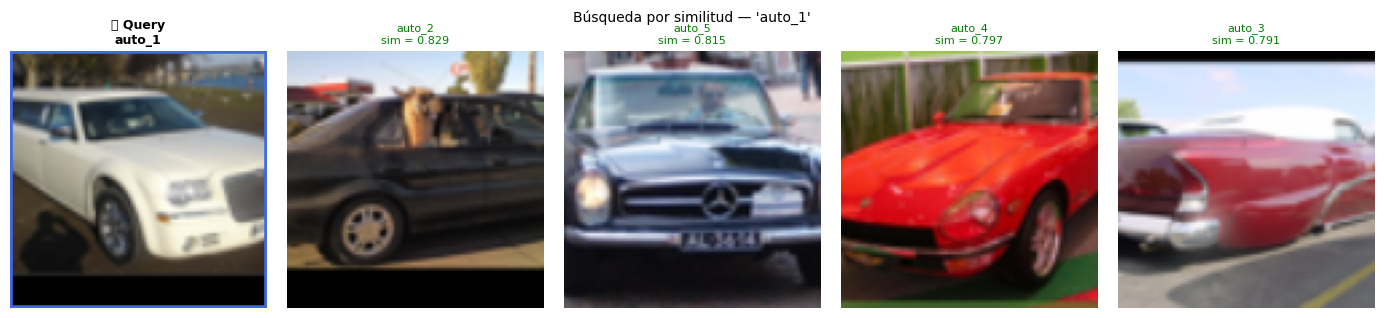

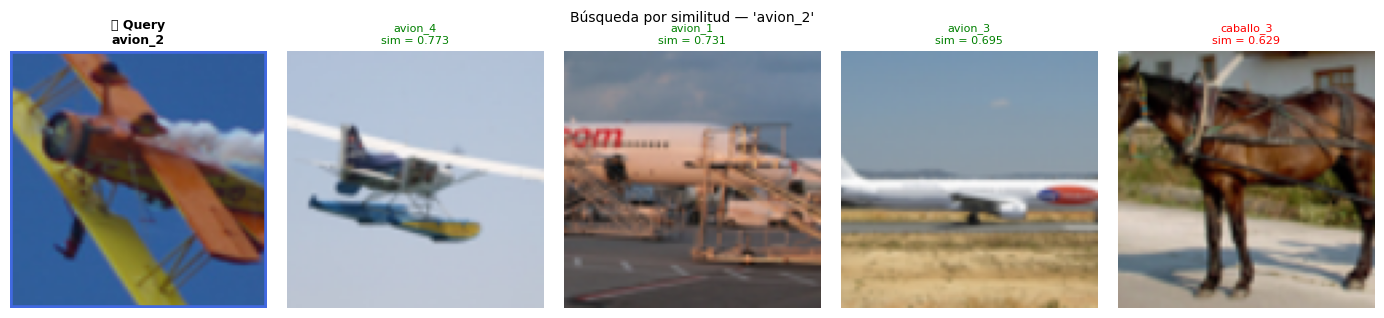

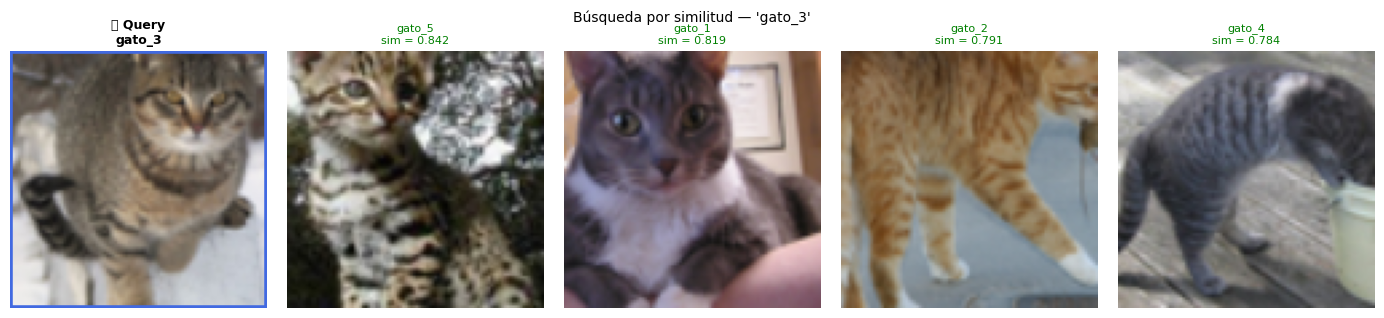

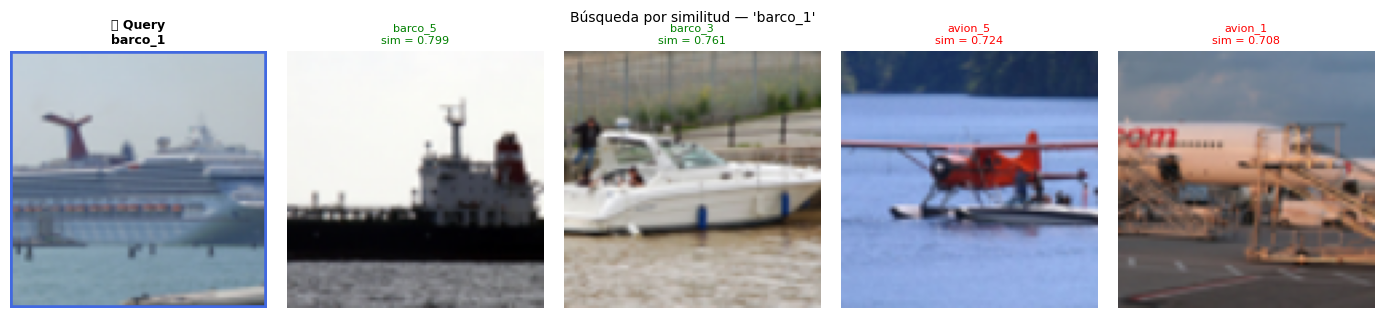

In [8]:
def buscar_similares(query, galeria_features, k=3, excluir_mismo=True):
    """Devuelve las k imágenes más similares al query, ordenadas por similitud."""
    q = galeria_features[query]
    sims = {}
    for nombre, feat in galeria_features.items():
        if excluir_mismo and nombre == query:
            continue
        sims[nombre] = F.cosine_similarity(q.unsqueeze(0), feat.unsqueeze(0)).item()
    return sorted(sims.items(), key=lambda x: x[1], reverse=True)[:k]


def visualizar_busqueda(query, galeria_features, imagenes_pil, k=4):
    resultados = buscar_similares(query, galeria_features, k=k)
    fig, axes = plt.subplots(1, k + 1, figsize=(2.8 * (k + 1), 3.2))

    # Query
    axes[0].imshow(imagenes_pil[query])
    axes[0].set_title(f"\U0001f50d Query\n{query}", fontsize=9, fontweight="bold")
    axes[0].axis("off")
    rect = plt.Rectangle([0, 0], 1, 1, fill=False, edgecolor="royalblue",
                          lw=4, transform=axes[0].transAxes)
    axes[0].add_patch(rect)

    for ax, (nombre, sim) in zip(axes[1:], resultados):
        ax.imshow(imagenes_pil[nombre])
        clase_q = query.rsplit("_", 1)[0]
        clase_r = nombre.rsplit("_", 1)[0]
        color = "green" if clase_q == clase_r else "red"
        ax.set_title(f"{nombre}\nsim = {sim:.3f}", fontsize=8, color=color)
        ax.axis("off")

    plt.suptitle(f"Búsqueda por similitud — '{query}'", fontsize=10)
    plt.tight_layout()
    plt.show()


# Queries de distintas categorías
for query in ["perro_1", "auto_1", "avion_2", "gato_3", "barco_1"]:
    visualizar_busqueda(query, features, imagenes_pil, k=4)

## 2.3 Visualización del espacio de features (PCA 2D)

Los vectores de 2048 dimensiones son imposibles de visualizar directamente. **PCA** (Análisis de Componentes Principales) los proyecta a 2D conservando la mayor varianza posible.

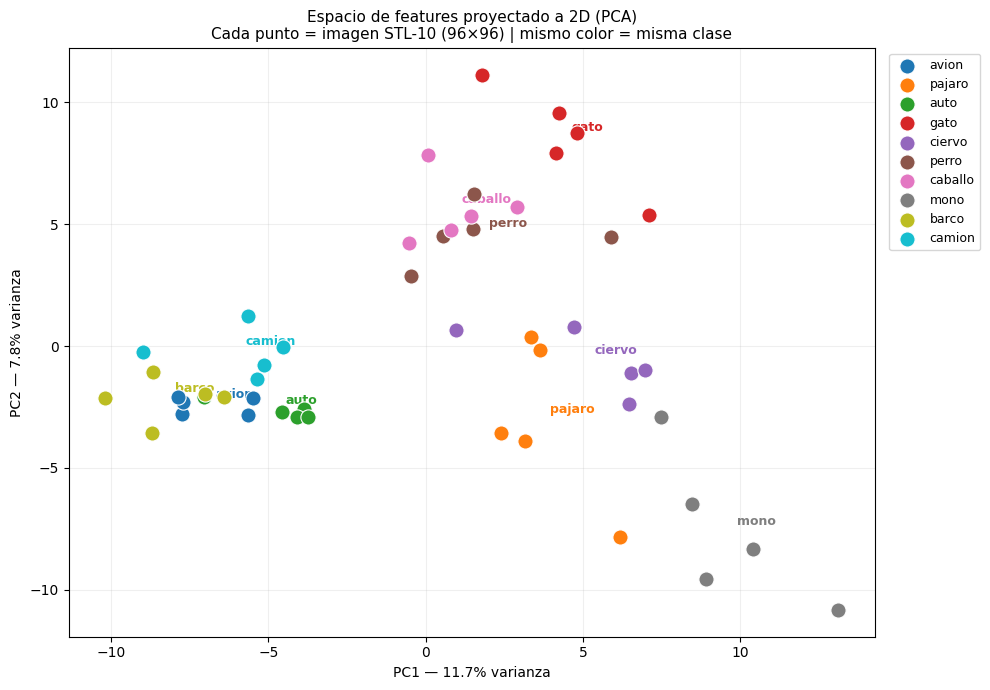

Varianza explicada por 2 componentes: 19.5%

¿Qué observás? ¿Los perros están cerca de otros perros? ¿Los autos entre sí?


In [9]:
X             = torch.stack(list(features.values())).numpy()   # (50, 2048)
clases_labels = [k.rsplit("_", 1)[0] for k in features.keys()]

pca  = PCA(n_components=2)
X_2d = pca.fit_transform(X)

COLORES = plt.cm.tab10(np.linspace(0, 1, len(CLASES_GALERIA)))
clase_a_color = {c: COLORES[i] for i, c in enumerate(CLASES_GALERIA)}

fig, ax = plt.subplots(figsize=(10, 7))
for clase in CLASES_GALERIA:
    mask = np.array([c == clase for c in clases_labels])
    pts  = X_2d[mask]
    ax.scatter(pts[:, 0], pts[:, 1], s=120, color=clase_a_color[clase],
               label=clase, zorder=4, edgecolors="white", lw=0.8)
    cx, cy = pts[:, 0].mean(), pts[:, 1].mean()
    ax.annotate(clase, (cx, cy), fontsize=9, fontweight="bold",
                color=clase_a_color[clase],
                xytext=(5, 5), textcoords="offset points")

ax.set_title("Espacio de features proyectado a 2D (PCA)\n"
             "Cada punto = imagen STL-10 (96×96) | mismo color = misma clase",
             fontsize=11)
ax.set_xlabel(f"PC1 — {pca.explained_variance_ratio_[0]*100:.1f}% varianza")
ax.set_ylabel(f"PC2 — {pca.explained_variance_ratio_[1]*100:.1f}% varianza")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

exp = sum(pca.explained_variance_ratio_[:2]) * 100
print(f"Varianza explicada por 2 componentes: {exp:.1f}%")
print("\n¿Qué observás? ¿Los perros están cerca de otros perros? ¿Los autos entre sí?")

---
# 3. Transfer Learning y Fine-Tuning

## 3.1 Dos estrategias

| Estrategia | Descripción | Cuándo usarla |
|---|---|---|
| **Feature Extraction** | Congelar toda la red, entrenar solo la cabeza | Dataset pequeño (<1 K imágenes), tarea similar a ImageNet |
| **Fine-Tuning** | Descongelar (parte de) la red y entrenar todo | Dataset mediano/grande, mayor capacidad de adaptación |

En ambos casos **partimos de pesos pre-entrenados** — no entrenamos desde cero.

```
Feature Extraction          Fine-Tuning
────────────────────        ────────────────────
[Backbone]  🔒 frozen       [Backbone]  🔓 unfrozen (LR bajo)
    ↓                           ↓
[Nueva Head] 🔥 trainable   [Nueva Head] 🔥 trainable (LR normal)
```

## 3.2 ResNet18 para CIFAR-10

Usamos ResNet18 (más liviana que ResNet50) y la adaptamos a CIFAR-10 (10 clases).

**¿Por qué ResNet18 y no ResNet50?**
- CIFAR-10 son imágenes 32×32 — la capacidad de ResNet50 es excesiva
- ResNet18 entrena ~3× más rápido
- El concepto de transfer learning es idéntico

In [10]:
import torch.optim as optim
from torch.utils.data import DataLoader

# ── 1. Cargamos ResNet18 pre-entrenado ────────────────────────────────────────
modelo_ft = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

print("Cabeza original de ResNet18 (ImageNet):")
print(f"  avgpool: {modelo_ft.avgpool}")
print(f"  fc:      {modelo_ft.fc}   → 1000 clases ImageNet")

# ── 2. Reemplazamos la cabeza para CIFAR-10 (10 clases) ───────────────────────
NUM_CLASES = 10
DIM_FEATURES = modelo_ft.fc.in_features   # 512 para ResNet18
modelo_ft.fc = nn.Linear(DIM_FEATURES, NUM_CLASES)
modelo_ft = modelo_ft.to(device)

print(f"\nNueva cabeza para CIFAR-10:")
print(f"  fc: {modelo_ft.fc}   → {NUM_CLASES} clases")

# ── 3. Parámetros totales vs entrenables ──────────────────────────────────────
total_p    = sum(p.numel() for p in modelo_ft.parameters())
train_p    = sum(p.numel() for p in modelo_ft.parameters() if p.requires_grad)
print(f"\nParámetros totales:      {total_p:,}")
print(f"Parámetros entrenables:  {train_p:,}")

Cabeza original de ResNet18 (ImageNet):
  avgpool: AdaptiveAvgPool2d(output_size=(1, 1))
  fc:      Linear(in_features=512, out_features=1000, bias=True)   → 1000 clases ImageNet

Nueva cabeza para CIFAR-10:
  fc: Linear(in_features=512, out_features=10, bias=True)   → 10 clases

Parámetros totales:      11,181,642
Parámetros entrenables:  11,181,642


## 3.3 Dataset y Dataloaders

Usamos CIFAR-10 con un **subconjunto reducido** para que el entrenamiento sea rápido en clase.
El preprocesamiento incluye el `Resize` a 64×64 porque ResNet18 espera entradas más grandes que 32×32.

In [11]:
# Las Secciones 1-2 usan STL-10; el fine-tuning usa CIFAR-10 (ya descargado, más rápido)
CLASES_CIFAR = ["avion", "auto", "pajaro", "gato", "ciervo",
                "perro", "rana", "caballo", "barco", "camion"]

transform_train = T.Compose([
    T.Resize(64),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
transform_val = T.Compose([
    T.Resize(64),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

cifar_train_full = datasets.CIFAR10("./data", train=True,  download=True, transform=transform_train)
cifar_val_full   = datasets.CIFAR10("./data", train=False, download=True, transform=transform_val)

N_TRAIN, N_VAL = 8000, 2000
subset_train = torch.utils.data.Subset(cifar_train_full, range(N_TRAIN))
subset_val   = torch.utils.data.Subset(cifar_val_full,   range(N_VAL))

loader_train = DataLoader(subset_train, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
loader_val   = DataLoader(subset_val,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train:  {len(subset_train)} imágenes  ({len(loader_train)} batches de 64)")
print(f"Val:    {len(subset_val)} imágenes  ({len(loader_val)} batches de 64)")

100.0%
/home/tino/Documentos/Projects/facultad/CV/IA5.2_Computer_Vision/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train:  8000 imágenes  (125 batches de 64)
Val:    2000 imágenes  (32 batches de 64)


## 3.4 Funciones de entrenamiento y evaluación

In [12]:
def entrenar_epoca(modelo, loader, criterion, optimizer):
    modelo.train()
    total_loss, correctas, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = modelo(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correctas  += (logits.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, 100 * correctas / total

def evaluar(modelo, loader, criterion):
    modelo.eval()
    total_loss, correctas, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = modelo(imgs)
            loss   = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            correctas  += (logits.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, 100 * correctas / total

criterion = nn.CrossEntropyLoss()

## 3.5 Estrategia 1 — Feature Extraction (solo la cabeza)

Congelamos todos los parámetros del backbone. Solo la nueva `fc` es entrenable.

In [13]:
# ── Reiniciamos el modelo y congelamos el backbone ────────────────────────────
modelo_fe = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for param in modelo_fe.parameters():
    param.requires_grad = False   # ← congelar todo

modelo_fe.fc = nn.Linear(DIM_FEATURES, NUM_CLASES)   # nueva cabeza (entrenable por defecto)
modelo_fe = modelo_fe.to(device)

n_train = sum(p.numel() for p in modelo_fe.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in modelo_fe.parameters())
print(f"Parámetros entrenables: {n_train:,} / {n_total:,}  ({100*n_train/n_total:.1f}%)")

optimizer_fe = optim.Adam(filter(lambda p: p.requires_grad, modelo_fe.parameters()), lr=1e-3)

hist_fe = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
N_EPOCHS_FE = 5

print(f"\nEntrenando {N_EPOCHS_FE} épocas (Feature Extraction)...")
for ep in range(1, N_EPOCHS_FE + 1):
    tr_l, tr_a = entrenar_epoca(modelo_fe, loader_train, criterion, optimizer_fe)
    vl_l, vl_a = evaluar(modelo_fe, loader_val, criterion)
    hist_fe["train_loss"].append(tr_l); hist_fe["train_acc"].append(tr_a)
    hist_fe["val_loss"].append(vl_l);   hist_fe["val_acc"].append(vl_a)
    print(f"  Época {ep}/{N_EPOCHS_FE}  |  train loss {tr_l:.4f}  acc {tr_a:.1f}%  "
          f"|  val loss {vl_l:.4f}  acc {vl_a:.1f}%")

Parámetros entrenables: 5,130 / 11,181,642  (0.0%)

Entrenando 5 épocas (Feature Extraction)...
  Época 1/5  |  train loss 1.6730  acc 43.1%  |  val loss 1.2997  acc 57.5%
  Época 2/5  |  train loss 1.2340  acc 58.1%  |  val loss 1.2082  acc 59.1%
  Época 3/5  |  train loss 1.1451  acc 61.7%  |  val loss 1.1753  acc 60.9%
  Época 4/5  |  train loss 1.0999  acc 62.6%  |  val loss 1.1738  acc 60.0%
  Época 5/5  |  train loss 1.0871  acc 63.0%  |  val loss 1.1527  acc 60.5%


## 3.6 Estrategia 2 — Fine-Tuning (toda la red)

Descongelamos el backbone y entrenamos todo, con una **tasa de aprendizaje más baja** para el backbone (para no destruir los pesos pre-entrenados) y normal para la cabeza.

In [14]:
# ── Fine-tuning completo ──────────────────────────────────────────────────────
modelo_ft2 = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
modelo_ft2.fc = nn.Linear(DIM_FEATURES, NUM_CLASES)
modelo_ft2 = modelo_ft2.to(device)

# Dos grupos de parámetros con distintas LR
params_backbone = [p for name, p in modelo_ft2.named_parameters() if "fc" not in name]
params_cabeza   = list(modelo_ft2.fc.parameters())

optimizer_ft2 = optim.Adam([
    {"params": params_backbone, "lr": 1e-4},   # LR baja para backbone
    {"params": params_cabeza,   "lr": 1e-3},   # LR normal para cabeza
])

n_train2 = sum(p.numel() for p in modelo_ft2.parameters() if p.requires_grad)
n_total2 = sum(p.numel() for p in modelo_ft2.parameters())
print(f"Parámetros entrenables: {n_train2:,} / {n_total2:,}  ({100*n_train2/n_total2:.1f}%)")

hist_ft2 = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
N_EPOCHS_FT = 5

print(f"\nEntrenando {N_EPOCHS_FT} épocas (Fine-Tuning completo)...")
for ep in range(1, N_EPOCHS_FT + 1):
    tr_l, tr_a = entrenar_epoca(modelo_ft2, loader_train, criterion, optimizer_ft2)
    vl_l, vl_a = evaluar(modelo_ft2, loader_val, criterion)
    hist_ft2["train_loss"].append(tr_l); hist_ft2["train_acc"].append(tr_a)
    hist_ft2["val_loss"].append(vl_l);   hist_ft2["val_acc"].append(vl_a)
    print(f"  Época {ep}/{N_EPOCHS_FT}  |  train loss {tr_l:.4f}  acc {tr_a:.1f}%  "
          f"|  val loss {vl_l:.4f}  acc {vl_a:.1f}%")

Parámetros entrenables: 11,181,642 / 11,181,642  (100.0%)

Entrenando 5 épocas (Fine-Tuning completo)...
  Época 1/5  |  train loss 0.9833  acc 66.2%  |  val loss 0.6184  acc 79.0%
  Época 2/5  |  train loss 0.4185  acc 86.3%  |  val loss 0.5242  acc 82.7%
  Época 3/5  |  train loss 0.2427  acc 91.9%  |  val loss 0.5462  acc 82.2%
  Época 4/5  |  train loss 0.1489  acc 95.5%  |  val loss 0.5713  acc 82.7%
  Época 5/5  |  train loss 0.1161  acc 96.1%  |  val loss 0.5995  acc 82.8%


## 3.7 Comparación de estrategias

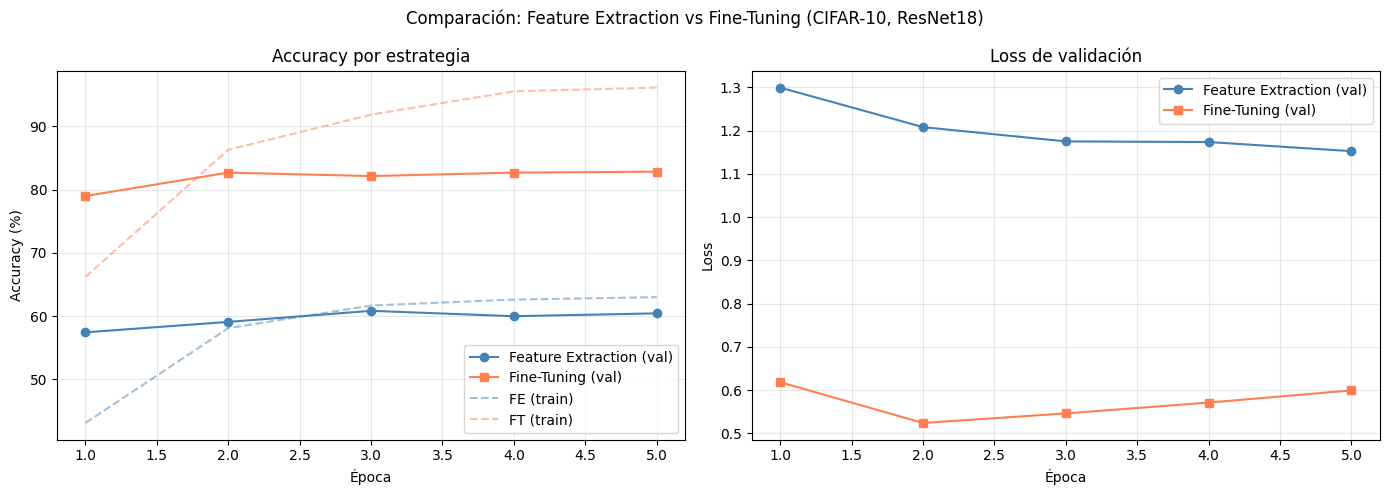


Resumen final:
  Feature Extraction: val acc = 60.5%
  Fine-Tuning:        val acc = 82.8%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epocas = range(1, N_EPOCHS_FE + 1)

# Accuracy
ax = axes[0]
ax.plot(epocas, hist_fe["val_acc"],  "o-", color="steelblue",  label="Feature Extraction (val)")
ax.plot(epocas, hist_ft2["val_acc"], "s-", color="coral",      label="Fine-Tuning (val)")
ax.plot(epocas, hist_fe["train_acc"], "--", color="steelblue",  alpha=0.5, label="FE (train)")
ax.plot(epocas, hist_ft2["train_acc"],"--", color="coral",      alpha=0.5, label="FT (train)")
ax.set_xlabel("Época"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy por estrategia"); ax.legend(); ax.grid(True, alpha=0.3)

# Loss
ax = axes[1]
ax.plot(epocas, hist_fe["val_loss"],   "o-", color="steelblue", label="Feature Extraction (val)")
ax.plot(epocas, hist_ft2["val_loss"],  "s-", color="coral",     label="Fine-Tuning (val)")
ax.set_xlabel("Época"); ax.set_ylabel("Loss")
ax.set_title("Loss de validación"); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Comparación: Feature Extraction vs Fine-Tuning (CIFAR-10, ResNet18)", fontsize=12)
plt.tight_layout()
plt.show()

print("\nResumen final:")
print(f"  Feature Extraction: val acc = {hist_fe['val_acc'][-1]:.1f}%")
print(f"  Fine-Tuning:        val acc = {hist_ft2['val_acc'][-1]:.1f}%")

## 3.8 Inferencia — visualizando predicciones del modelo fine-tuneado

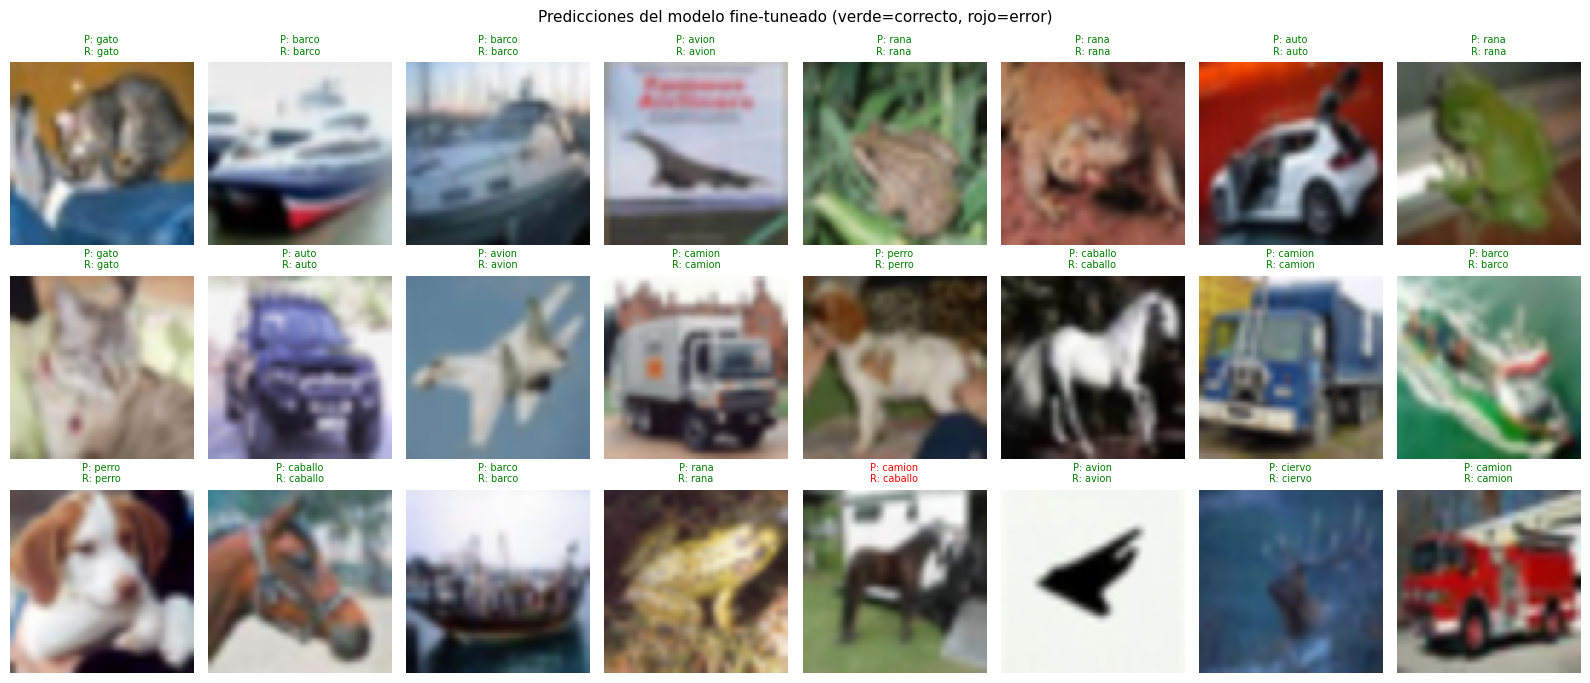

In [16]:
modelo_ft2.eval()
imgs_batch, labels_batch = next(iter(loader_val))
imgs_batch = imgs_batch.to(device)

with torch.no_grad():
    logits = modelo_ft2(imgs_batch)
    probs  = torch.softmax(logits, dim=1)

preds = probs.argmax(1).cpu()

# Desnormalizamos para visualizar
mean_v = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_v  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
imgs_vis = (imgs_batch.cpu() * std_v + mean_v).clamp(0, 1)

fig, axes = plt.subplots(3, 8, figsize=(16, 7))
for i, ax in enumerate(axes.flat):
    img = imgs_vis[i].permute(1, 2, 0).numpy()
    ax.imshow(img)
    pred  = preds[i].item()
    real  = labels_batch[i].item()
    color = "green" if pred == real else "red"
    ax.set_title(f"P: {CLASES_CIFAR[pred]}\nR: {CLASES_CIFAR[real]}",
                 fontsize=7, color=color)
    ax.axis("off")

plt.suptitle("Predicciones del modelo fine-tuneado (verde=correcto, rojo=error)", fontsize=11)
plt.tight_layout()
plt.show()

---
# 4. Detección de Objetos en Imágenes

Hasta ahora clasificamos imágenes completas. La **detección** responde a una pregunta más rica: *¿qué objetos hay y dónde están?*

## 4.1 Arquitectura de un detector

```
Imagen
  ↓
[Backbone]      ← extrae features (ya lo conocemos)
  ↓
[Neck — FPN]    ← combina features de distintas escalas (nuevo)
  ↓
[Head — RPN + RoIPool + Classifier] ← propone y clasifica regiones
  ↓
[boxes, labels, scores]
```

**Faster R-CNN** fue un hito histórico (2015) porque unificó la propuesta de regiones y la clasificación en una sola red diferenciable, entrenada end-to-end.

## 4.2 Faster R-CNN pre-entrenado en COCO

COCO tiene **80 categorías** de objetos cotidianos. Cargamos el modelo directamente de Torchvision — ya incluye los pesos y no requiere entrenamiento.

In [17]:
# COCO 2017 — 80 clases + background
COCO_CLASES = [
    "__background__", "person", "bicycle", "car", "motorcycle", "airplane",
    "bus", "train", "truck", "boat", "traffic light", "fire hydrant", "N/A",
    "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse",
    "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "N/A", "backpack",
    "umbrella", "N/A", "N/A", "handbag", "tie", "suitcase", "frisbee", "skis",
    "snowboard", "sports ball", "kite", "baseball bat", "baseball glove",
    "skateboard", "surfboard", "tennis racket", "bottle", "N/A", "wine glass",
    "cup", "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich",
    "orange", "broccoli", "carrot", "hot dog", "pizza", "donut", "cake",
    "chair", "couch", "potted plant", "bed", "N/A", "dining table", "N/A",
    "N/A", "toilet", "N/A", "tv", "laptop", "mouse", "remote", "keyboard",
    "cell phone", "microwave", "oven", "toaster", "sink", "refrigerator",
    "N/A", "book", "clock", "vase", "scissors", "teddy bear", "hair drier",
    "toothbrush",
]

print("Cargando Faster R-CNN (ResNet50 + FPN, pre-entrenado en COCO)...")
detector = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
detector.eval()
print(f"Modelo cargado  ✓  ({sum(p.numel() for p in detector.parameters()):,} parámetros)")

Cargando Faster R-CNN (ResNet50 + FPN, pre-entrenado en COCO)...
Modelo cargado  ✓  (41,755,286 parámetros)


[OK] Web: https://img.freepik.com/foto-gratis/comunidad-jovenes-p...


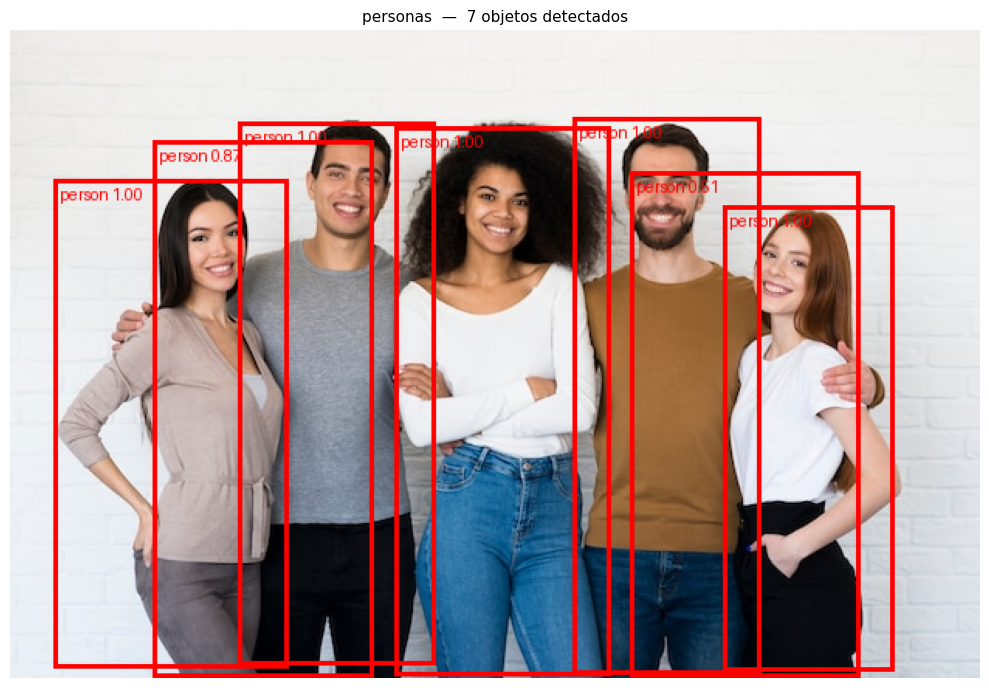

  Clases detectadas: ['person']

[OK] Web: https://www.diariodecultura.com.ar/wp-content/uploads/2...


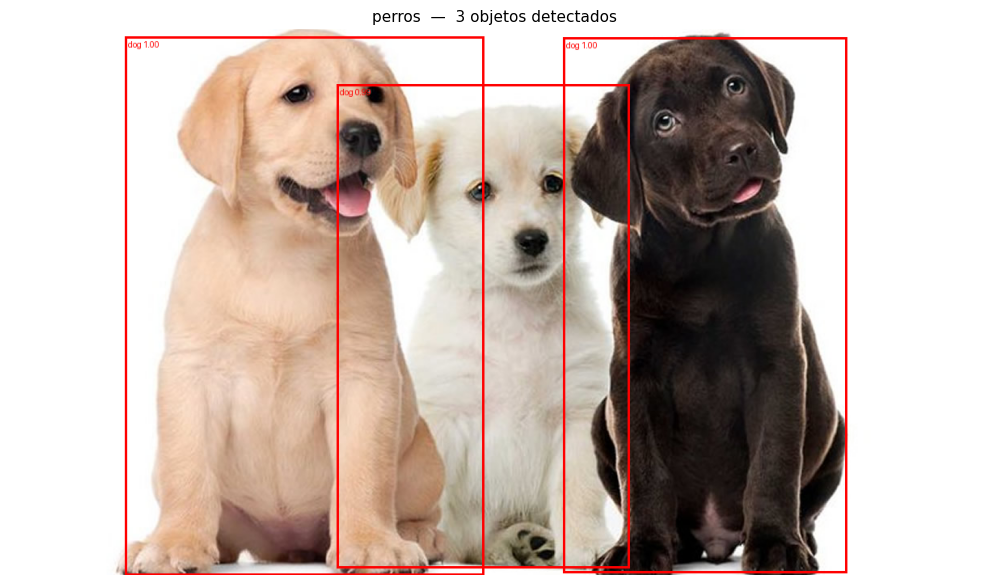

  Clases detectadas: ['dog']

[OK] Web: https://nupec.com/wp-content/uploads/2021/12/group-of-c...


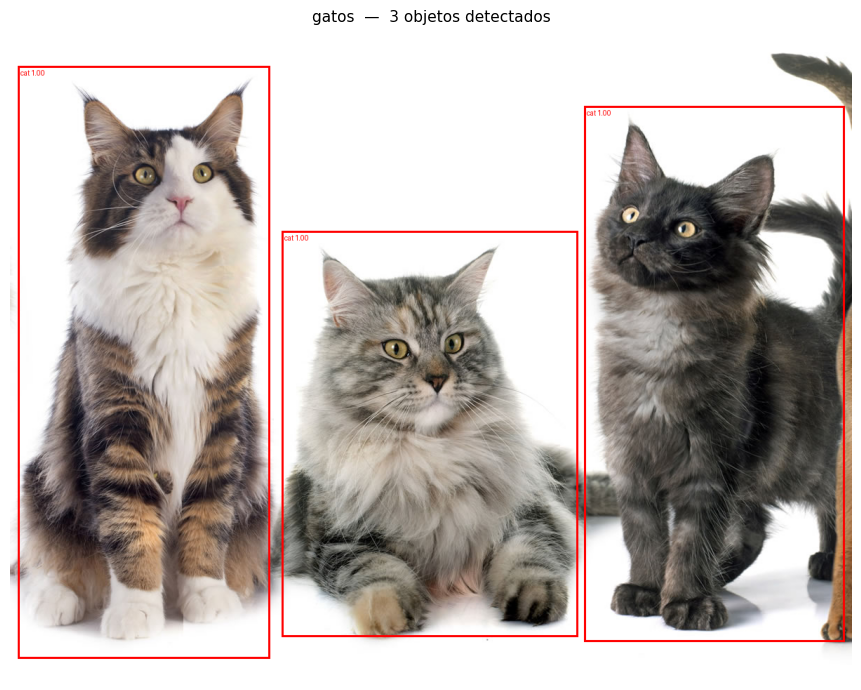

  Clases detectadas: ['cat']

[OK] Web: https://static.vecteezy.com/system/resources/previews/0...


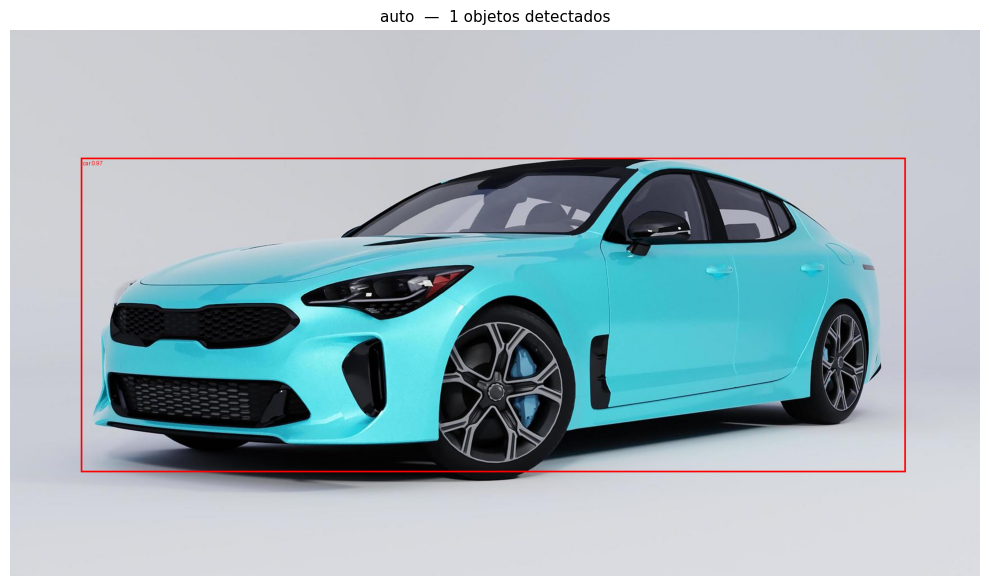

  Clases detectadas: ['car']



In [18]:
def detectar(img_pil, modelo, umbral=0.5):
    """Devuelve boxes, labels y scores filtrados por umbral de confianza."""
    img_t = TF.to_tensor(img_pil)
    with torch.no_grad():
        pred = modelo([img_t])[0]
    mask = pred["scores"] > umbral
    return pred["boxes"][mask], pred["labels"][mask], pred["scores"][mask]


def visualizar_deteccion(img_pil, boxes, labels, scores, clases, titulo=""):
    img_t = (TF.to_tensor(img_pil) * 255).to(torch.uint8)
    if len(boxes) == 0:
        print(f"  {titulo}: sin detecciones con el umbral actual")
        plt.figure(figsize=(6, 4))
        plt.imshow(img_pil)
        plt.title(f"{titulo} — sin detecciones"); plt.axis("off"); plt.show()
        return
    etiq = [f"{clases[l.item()]} {s:.2f}" for l, s in zip(labels, scores)]
    img_boxes = draw_bounding_boxes(img_t, boxes.int(), labels=etiq,
                                    colors=["red"] * len(etiq), width=3)
    plt.figure(figsize=(10, 7))
    plt.imshow(img_boxes.permute(1, 2, 0).numpy())
    plt.title(f"{titulo}  —  {len(boxes)} objetos detectados", fontsize=11)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# Imágenes con objetos presentes en COCO (personas, animales, vehículos)
IMAGENES_DET = {
    "personas":  (None, "https://img.freepik.com/foto-gratis/comunidad-jovenes-positivos-juntos_23-2148431352.jpg", (180, 160, 140)),
    "perros":    (None, "https://www.diariodecultura.com.ar/wp-content/uploads/2021/01/perros.jpg", (190, 150, 80)),
    "gatos":     (None, "https://nupec.com/wp-content/uploads/2021/12/group-of-cat-2021-08-26-17-35-49-utc.jpg", (110, 90, 75)),
    "auto":      (None, "https://static.vecteezy.com/system/resources/previews/008/585/294/non_2x/3d-rendering-sport-blue-car-on-white-bakcground-jpg-free-photo.jpg", (50, 70, 140)),
}

# Guardamos las imágenes en imagenes_det_pil para reutilizarlas en la simulación de video
imagenes_det_pil = {}

for nombre, (ruta, url, color) in IMAGENES_DET.items():
    img = cargar_imagen(ruta, url, color)
    imagenes_det_pil[nombre] = img
    boxes, labels, scores = detectar(img, detector, umbral=0.5)
    visualizar_deteccion(img, boxes, labels, scores, COCO_CLASES, titulo=nombre)
    clases_det = list({COCO_CLASES[l.item()] for l in labels})
    print(f"  Clases detectadas: {clases_det}\n")

## 4.3 Detección en múltiples imágenes — panel comparativo

Visualizamos las detecciones sobre todas las imágenes cargadas en una grilla para comparar cómo el modelo responde a distintas categorías de objetos y escenas.

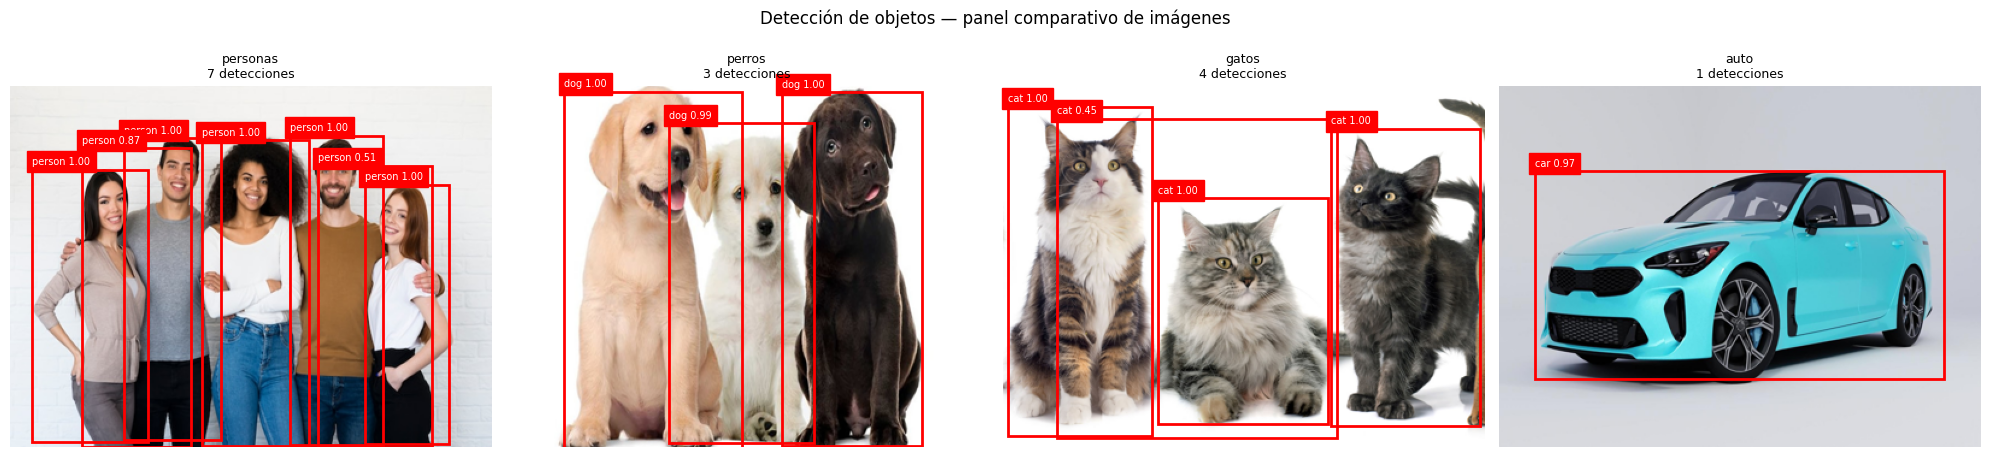

In [19]:
# Panel comparativo: detección sobre las cuatro imágenes de ejemplo
imgs_items = list(imagenes_det_pil.items())
n_imgs     = len(imgs_items)

fig, axes = plt.subplots(1, n_imgs, figsize=(5 * n_imgs, 5))
if n_imgs == 1:
    axes = [axes]

for ax, (nombre, img) in zip(axes, imgs_items):
    boxes, labels, scores = detectar(img, detector, umbral=0.4)

    ax.imshow(img.resize((400, 300)))
    ax.set_title(f"{nombre}\n{len(boxes)} detecciones", fontsize=9)
    ax.axis("off")

    orig_w, orig_h = img.size
    sx, sy = 400 / orig_w, 300 / orig_h
    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box.tolist()
        rect = plt.Rectangle(
            (x1 * sx, y1 * sy), (x2 - x1) * sx, (y2 - y1) * sy,
            linewidth=2, edgecolor="red", facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(x1 * sx, max(y1 * sy - 4, 0),
                f"{COCO_CLASES[label.item()]} {score:.2f}",
                color="white", fontsize=7, backgroundcolor="red")

plt.suptitle("Detección de objetos — panel comparativo de imágenes", fontsize=12)
plt.tight_layout()
plt.show()

---
# Ejercicios

## Ejercicio 1: Búsqueda inversa con una imagen nueva

1. Descargá (o usá `imagen_sintetica`) una imagen que no esté en la galería.
2. Extraele el vector de features con `extractor`.
3. Usá `buscar_similares` para encontrar las 3 más cercanas de la galería.
4. Visualizá el resultado con `visualizar_busqueda`.

¿El resultado tiene sentido semántico? ¿Qué cambiaría si usaras un modelo entrenado en un dominio más específico (ej: solo razas de perros)?

In [20]:
# Ejercicio 1: Completar aquí

# 1. Cargar una imagen nueva
# nueva_img = cargar_imagen(None, "URL_DE_TU_IMAGEN", (128, 128, 128))

# 2. Extraer feature vector
# nueva_img_t = transform_imagenet(nueva_img).unsqueeze(0)
# with torch.no_grad():
#     nueva_feat = extractor(nueva_img_t).squeeze(0)

# 3. Agregar a la galería y buscar similares
# features["mi_imagen"] = nueva_feat
# imagenes_pil["mi_imagen"] = nueva_img
# visualizar_busqueda("mi_imagen", features, imagenes_pil, k=3)

## Ejercicio 2: Análisis del fine-tuning — Matriz de Confusión

Usando el modelo fine-tuneado `modelo_ft2`:
1. Recorrés `loader_val` completo y recolectás todas las predicciones y etiquetas reales.
2. Construís la matriz de confusión (podés usar `sklearn.metrics.confusion_matrix`).
3. La visualizás como heatmap con `plt.imshow`.

¿Qué clases confunde más el modelo? ¿Tienen sentido visual esas confusiones?

In [21]:
# Ejercicio 2: Completar aquí
from sklearn.metrics import confusion_matrix
import seaborn as sns   # opcional, para mejor visualización

# 1. Recolectar todas las predicciones
# all_preds, all_labels = [], []
# modelo_ft2.eval()
# with torch.no_grad():
#     for imgs, labels in loader_val:
#         imgs = imgs.to(device)
#         logits = modelo_ft2(imgs)
#         preds = logits.argmax(1).cpu()
#         all_preds.extend(preds.numpy())
#         all_labels.extend(labels.numpy())

# 2. Construir y visualizar la matriz de confusión
# cm = confusion_matrix(all_labels, all_preds)
# fig, ax = plt.subplots(figsize=(9, 8))
# im = ax.imshow(cm, cmap="Blues")
# ax.set_xticks(range(10)); ax.set_xticklabels(CLASES_CIFAR, rotation=45, ha="right")
# ax.set_yticks(range(10)); ax.set_yticklabels(CLASES_CIFAR)
# plt.colorbar(im, ax=ax)
# ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
# ax.set_title("Matriz de Confusión — Fine-Tuning ResNet18 en CIFAR-10")
# for i in range(10):
#     for j in range(10):
#         ax.text(j, i, cm[i,j], ha="center", va="center", fontsize=8,
#                 color="white" if cm[i,j] > cm.max()*0.5 else "black")
# plt.tight_layout()
# plt.show()

## Ejercicio 3: Umbral de detección y su efecto

Con el detector Faster R-CNN y una imagen a tu elección:
1. Corré `detectar` con umbrales de confianza: `[0.3, 0.5, 0.7, 0.9]`.
2. Visualizá las detecciones de cada umbral en una grilla 1×4.
3. Anotá cuántos objetos se detectan para cada umbral.

¿Qué trade-off existe entre umbral bajo y umbral alto? ¿Qué términos (de las clases de Eze) describen este fenómeno?

In [22]:
# Ejercicio 3: Completar aquí

# img_ej3 = cargar_imagen(None, "URL_O_RUTA_LOCAL", (128, 128, 128))
# umbrales = [0.3, 0.5, 0.7, 0.9]

# fig, axes = plt.subplots(1, len(umbrales), figsize=(16, 5))
# for ax, u in zip(axes, umbrales):
#     boxes, labels, scores = detectar(img_ej3, detector, umbral=u)
#     # TODO: visualizar en ax con el mismo esquema de la Sección 5.4
#     ax.set_title(f"umbral={u}\n{len(boxes)} detecciones")
#     ax.axis("off")
# plt.suptitle("Efecto del umbral de confianza en la detección", fontsize=12)
# plt.tight_layout()
# plt.show()

## Ejercicio 4: Espacio de features antes y después del fine-tuning

En la Sección 1 usamos el backbone de ResNet50 pre-entrenado como extractor de features. En la Sección 3 entrenamos un ResNet18 con fine-tuning en CIFAR-10.

1. Creá un extractor quitando la cabeza de `modelo_ft2` (similar a la Sección 1):
   ```python
   extractor_ft = torch.nn.Sequential(*list(modelo_ft2.children())[:-1])
   extractor_ft.eval()
   ```
2. Tomá 200 imágenes de `loader_val` y extraé sus features con:
   - El extractor fine-tuneado (`extractor_ft`)
   - Un ResNet18 **sin** fine-tuning (cargalo con `models.resnet18(weights="IMAGENET1K_V1")` y quitale la `fc`)
3. Aplicá PCA 2D a ambos conjuntos de features y graficarlos lado a lado, coloreando cada punto por clase CIFAR-10 (podés reutilizar el código de la Sección 2.3).

¿En cuál espacio están las clases más separadas? ¿Qué dice eso sobre el valor del fine-tuning para esta tarea?

In [23]:
# Ejercicio 4: Completar aquí

# 1. Extractor fine-tuneado
# extractor_ft = torch.nn.Sequential(*list(modelo_ft2.children())[:-1])
# extractor_ft.eval()

# 2. Extractor pre-entrenado sin fine-tuning
# backbone_orig = models.resnet18(weights="IMAGENET1K_V1")
# extractor_orig = torch.nn.Sequential(*list(backbone_orig.children())[:-1])
# extractor_orig.eval()

# 3. Recolectar 200 imágenes y etiquetas de loader_val
# feats_ft, feats_orig, etiquetas = [], [], []
# with torch.no_grad():
#     for imgs, lbls in loader_val:
#         feats_ft.append(extractor_ft(imgs).squeeze(-1).squeeze(-1))
#         feats_orig.append(extractor_orig(imgs).squeeze(-1).squeeze(-1))
#         etiquetas.append(lbls)
#         if sum(len(e) for e in etiquetas) >= 200:
#             break
# feats_ft   = torch.cat(feats_ft)[:200].numpy()
# feats_orig = torch.cat(feats_orig)[:200].numpy()
# etiquetas  = torch.cat(etiquetas)[:200].numpy()

# 4. PCA 2D y visualización lado a lado
# from sklearn.decomposition import PCA
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# for ax, feats, titulo in zip(axes,
#                               [feats_orig, feats_ft],
#                               ["Pre-entrenado (sin fine-tuning)", "Fine-tuneado en CIFAR-10"]):
#     coords = PCA(n_components=2).fit_transform(feats)
#     scatter = ax.scatter(coords[:, 0], coords[:, 1], c=etiquetas, cmap="tab10", s=15, alpha=0.8)
#     ax.set_title(titulo); ax.axis("off")
# fig.colorbar(scatter, ax=axes, ticks=range(10), label="Clase CIFAR-10")
# plt.tight_layout(); plt.show()